In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import CNN
import torch
import torch.nn as nn

In [2]:
# 导入训练好的模型文件
model = CNN.CNN()
model.load_state_dict(torch.load('/home/gracchus/code/UCAS-Deep-Learning-2026Spring/Lab1/model/cnn_mnist.pth'))

<All keys matched successfully>

In [3]:
# 利用测试集进行评估，并绘制混淆矩阵、ROC曲线、准确率召回率F1分数等图表
# 数据为MNIST测试集，可以使用torchvision.datasets.MNIST加载测试集数据
from torchvision import datasets, transforms
transform = transforms.Compose([transforms.ToTensor()])
test_dataset = datasets.MNIST(root='/home/gracchus/code/UCAS-Deep-Learning-2026Spring/Data/', train=False, transform=transform, download=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

In [4]:
# 开始评估，用GPU进行推理
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

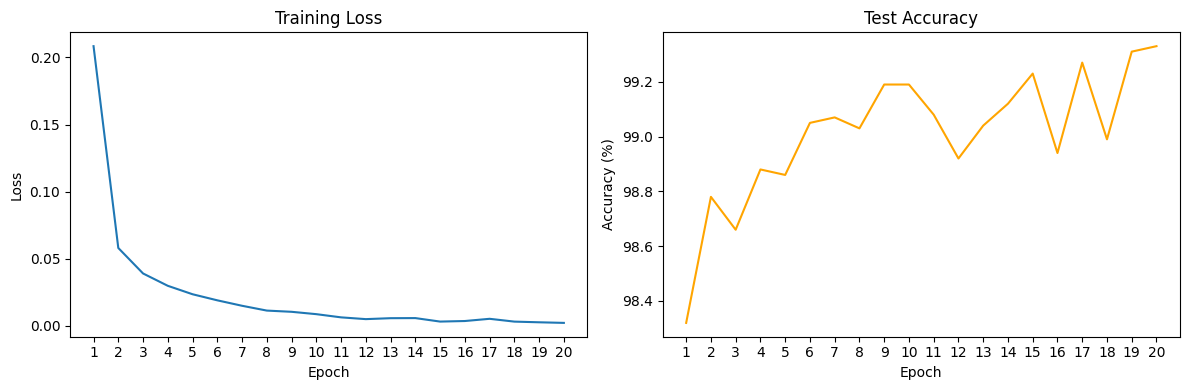

In [7]:
# 读取训练日志csv文件，绘制训练损失和测试准确率的变化曲线
log_df = pd.read_csv('/home/gracchus/code/UCAS-Deep-Learning-2026Spring/Lab1/logs/train_log.csv')
plt.style.use('default')  # 使用默认样式

plt.figure(figsize=(12, 4))

# 训练损失
plt.subplot(1, 2, 1)
plt.plot(log_df['epoch'], log_df['train_loss'], label='Train Loss')
plt.xticks(log_df['epoch'])  # 横轴使用整数
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
#plt.legend()

# 测试准确率（百分比）
plt.subplot(1, 2, 2)
plt.plot(log_df['epoch'], log_df['test_acc'] * 100, label='Test Accuracy', color='orange')  # 转换为百分比
plt.xticks(log_df['epoch'])  # 横轴使用整数
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Test Accuracy')
#plt.legend()

plt.tight_layout()
#plt.show()
plt.savefig('/home/gracchus/code/UCAS-Deep-Learning-2026Spring/Lab1/Figure/train_log.png')